# Бустинг - XGBoost, LightGBM и CatBoost

In [ ]:
# pip install catboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV # 2 вида поиска параметров

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping # для ранней остановки
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# DataFrame (используем вашу)
np.random.seed(42)
num_clients = 300
income = np.random.randint(30000, 100000, num_clients)
credit_history = np.random.rand(num_clients)
probability_of_loan = 0.5 * income + 10000 * credit_history + np.random.normal(0, 5000, num_clients)
loan_decision = (probability_of_loan > np.mean(probability_of_loan)).astype(int)
data = pd.DataFrame({'income': income, 'credit_history': credit_history, 'loan_decision': loan_decision})

In [ ]:
data

,income,credit_history,loan_decision
0,45795,0.590833,0
1,30860,0.030500,0
2,84886,0.037348,1
3,36265,0.822601,0
4,67194,0.360191,1
...,...,...,...
295,40966,0.633401,0
296,82921,0.240146,1
297,79726,0.075863,0
298,80300,0.128880,1


In [ ]:
# Подготовка данных
X = data[['income', 'credit_history']]
y = data['loan_decision']

#  Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#  Масштабирование признаков (рекомендуется для XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# XGBoost

## XGBoost просто

In [ ]:
# XGBoost для классификации
xgb = XGBClassifier(
    n_estimators=50,      # Количество деревьев (boosting rounds)
    learning_rate=0.1,     # Темп обучения (шаг градиентного спуска)0.001
    max_depth=3,           # Максимальная глубина дерева
    subsample=0.5,         # Доля образцов для обучения каждого дерева
    colsample_bytree=0.5,  # Доля признаков для обучения каждого дерева
    random_state=42,       # Зерно для воспроизводимости
    use_label_encoder=False, # Чтобы избежать предупреждения
    eval_metric='logloss'  # Метрика для оценки производительности (обязательно указать)
)

xgb.fit(X_train_scaled, y_train)



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [14:44:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#  Оценка модели
y_pred_xgb_t = xgb.predict(X_train_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

accuracy_xgb_t = accuracy_score(y_train, y_pred_xgb_t)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost: Accuracy train = {accuracy_xgb_t:.2f}")
print(f"XGBoost: Accuracy test = {accuracy_xgb:.2f}")

print("\nClassification Report (train):\n", classification_report(y_train, y_pred_xgb_t))
print("\nClassification Report (test):\n", classification_report(y_test, y_pred_xgb))

XGBoost: Accuracy train = 0.93
XGBoost: Accuracy test = 0.90

Classification Report (train):
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        80
           1       0.93      0.93      0.93        80

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160


Classification Report (test):
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.90      0.90      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



In [ ]:
# Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'income': [new_income], 'credit_history': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

loan_decision_new_client = xgb.predict(new_client_scaled)[0]
probability_of_loan_new_client = xgb.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {probability_of_loan_new_client:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - выдать): {loan_decision_new_client}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.68
Решение о выдаче кредита (1 - выдать, 0 - выдать): 1


##  XGBoost с RandomizedSearchCV

In [ ]:
#  XGBoost
param_grid = {
    'n_estimators': [50, 100, 200],       # Количество деревьев
    'learning_rate': [0.01, 0.1],   # Темп обучения
    'max_depth': [3, 5],             # Максимальная глубина дерева
    'subsample': [0.7, 0.9],        # Доля образцов для обучения
    'colsample_bytree': [0.7,  0.9]   # Доля признаков для обучения
}
# создаем объект RandomizedSearchCV
random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_iter=10,  # Количество случайных комбинаций для перебора
    verbose=0
)

random_search.fit(X_train_scaled, y_train)



RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.7, 0.9],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [3, 5],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.7, 0.9]},
                   scoring='accuracy')

In [ ]:
# Лучшая модель
best_xgb = random_search.best_estimator_
print("Лучшие параметры для XGBoost:", random_search.best_params_)

Лучшие параметры для XGBoost: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [ ]:
# Оценка модели
y_pred_xgb_t = best_xgb.predict(X_train_scaled)
y_pred_xgb = best_xgb.predict(X_test_scaled)

accuracy_xgb_t = accuracy_score(y_train, y_pred_xgb_t)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost: Accuracy train = {accuracy_xgb_t:.2f}")
print(f"XGBoost: Accuracy = {accuracy_xgb:.2f}")

print("\nClassification Report train:\n", classification_report(y_train, y_pred_xgb_t))
print("\nClassification Report text:\n", classification_report(y_test, y_pred_xgb))

XGBoost: Accuracy train = 0.95
XGBoost: Accuracy = 0.88

Classification Report train:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       118
           1       0.93      0.98      0.96       122

    accuracy                           0.95       240
   macro avg       0.96      0.95      0.95       240
weighted avg       0.96      0.95      0.95       240


Classification Report text:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.87      0.89        31

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [ ]:
#  Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'income': [new_income], 'credit_history': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

loan_decision_new_client = best_xgb.predict(new_client_scaled)[0]
probability_of_loan_new_client = best_xgb.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {probability_of_loan_new_client:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - выдать): {loan_decision_new_client}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.56
Решение о выдаче кредита (1 - выдать, 0 - выдать): 1


# LightGBM

In [ ]:
# LightGBM для классификации
lgbm = LGBMClassifier(
    n_estimators=50,        # Количество деревьев
    learning_rate=0.01,       # Темп обучения 0.1=переобучение
    max_depth=3,             # Максимальная глубина дерева
    num_leaves=5,           # Максимальное количество листьев в дереве (зависит от max_depth)
    min_child_samples =1 ,   # диапозон от 1 до кол-ва образцов в вашем train
    min_samples_leaf =1,   # диапозон от 1 до кол-ва
    subsample=0.5,           # Доля обучающих выборок для построения каждого дерева
    colsample_bytree=0.3,    # Доля признаков для построения каждого дерева
    random_state=42,        # Зерно для воспроизводимости
    metric='binary_logloss'  # Метрика оценки (указывать не обязательно, но можно, если нужна)
)

lgbm.fit(X_train_scaled, y_train)


[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=1, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=1, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Info] Number of positive: 122, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000031 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 163
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508333 -> initscore=0.033336
[LightGBM] [Info] Start training from score 0.033336


LGBMClassifier(colsample_bytree=0.3, learning_rate=0.01, max_depth=3,
               metric='binary_logloss', min_child_samples=1, min_samples_leaf=1,
               n_estimators=50, num_leaves=5, random_state=42, subsample=0.5)

In [ ]:
# Оценка модели
y_pred_lgbm_t = lgbm.predict(X_train_scaled)
y_pred_lgbm = lgbm.predict(X_test_scaled)

accuracy_lgbm_t = accuracy_score(y_train, y_pred_lgbm_t)
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)


print(f"LightGBM: Accuracy train= {accuracy_lgbm_t:.2f}")
print(f"LightGBM: Accuracy test= {accuracy_lgbm:.2f}")

print("\nClassification Report (train):\n", classification_report(y_train, y_pred_lgbm_t))
print("\nClassification Report (test):\n", classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=1, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=1, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
LightGBM: Accuracy train= 0.93
LightGBM: Accuracy test= 0.93

Classification Report (train):
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       118
           1       0.91      0.94      0.93       122

    accuracy                           0.93       240
   macro avg       0.93      0.92      0.92       240
weighted avg       0.93      0.93      0.92       240


Classification Report (test):
               precision    recall  f1-score   support

           0       0.96      0.90      0.93        29
           1       0.91      0.97      0.94        31

    accuracy                           0.93        60
   macro avg       0.94      0.93  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#  Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'income': [new_income], 'credit_history': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

loan_decision_new_client = lgbm.predict(new_client_scaled)[0]
probability_of_loan_new_client = lgbm.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {probability_of_loan_new_client:.2f}")

#  Настройка параметров LightGBM с RandomizedSearchCV


In [ ]:
param_dist = {
    'min_child_samples': np.arange(5, 21),       # Диапазон для min_child_samples
    'min_samples_leaf': np.arange(2, 11),         # Диапазон для min_samples_leaf
    'n_estimators': [50],  # Фиксируем количество деревьев (для простоты примера)
    'learning_rate': [0.1],  # Фиксируем learning rate
    'max_depth': [3],
    'num_leaves': [10],
    'subsample': [0.5],
    'colsample_bytree': [0.8],
    'random_state': [42]

}

random_search = RandomizedSearchCV(
    LGBMClassifier(metric='binary_logloss'), #metric уже указан
    param_distributions=param_dist,
    n_iter=20,  # Количество случайных комбинаций для перебора
    scoring='accuracy',  # Используем accuracy для оценки
    cv=3,         # Количество фолдов для кросс-валидации
    random_state=42,
    verbose=0
)

random_search.fit(X_train_scaled, y_train)

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=18, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=18, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Info] Number of positive: 81, number of negative: 79
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 110
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506250 -> initscore=0.025001
[LightGBM] [Info] Start training from score 0.025001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=6, will be overridden by min_samples_leaf=5. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=6, will be overridden by min_samples_leaf=5. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 82, number of negative: 78
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 110
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512500 -> initscore=0.050010
[LightGBM] [Info] Start training from score 0.050010
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=13, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=13, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Info] Number of positive: 81, number of negative: 79
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 110
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506250 -> initscore=0.025001
[LightGBM] [Info] Start training from score 0.025001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=8, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=8, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=8, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Info] Number of positive: 81, number of negative: 79
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000764 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 110
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506250 -> initscore=0.025001
[LightGBM] [Info] Start training from score 0.025001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

RandomizedSearchCV(cv=3, estimator=LGBMClassifier(metric='binary_logloss'),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.8],
                                        'learning_rate': [0.1],
                                        'max_depth': [3],
                                        'min_child_samples': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]),
                                        'min_samples_leaf': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'n_estimators': [50],
                                        'num_leaves': [10],
                                        'random_state': [42],
                                        'subsample': [0.5]},
                   random_state=42, scoring='accuracy')

In [ ]:
# Лучшая модель
best_lgbm = random_search.best_estimator_
print("Лучшие параметры для LightGBM:", random_search.best_params_)

Лучшие параметры для LightGBM: {'subsample': 0.5, 'random_state': 42, 'num_leaves': 10, 'n_estimators': 50, 'min_samples_leaf': np.int64(2), 'min_child_samples': np.int64(18), 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
# Оценка модели
y_pred_lgbm_t = best_lgbm.predict(X_train_scaled)
y_pred_lgbm = best_lgbm.predict(X_test_scaled)

accuracy_lgbm_t = accuracy_score(y_train, y_pred_lgbm_t)
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)

print(f"LightGBM: Accuracy train = {accuracy_lgbm_t:.2f}")
print(f"LightGBM: Accuracy  test = {accuracy_lgbm:.2f}")

print("\nClassification Report (train):\n", classification_report(y_train, y_pred_lgbm_t))
print("\nClassification Report (test):\n", classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=18, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=18, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
LightGBM: Accuracy train = 0.98
LightGBM: Accuracy  test = 0.93

Classification Report (train):
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       118
           1       0.96      1.00      0.98       122

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240


Classification Report (test):
               precision    recall  f1-score   support

           0       0.96      0.90      0.93        29
           1       0.91      0.97      0.94        31

    accuracy                           0.93        60
   macro avg       0.94      0

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# пример  LightGBM  с ранней остановкой

In [ ]:
# 5. LightGBM с ранней остановкой
lgbm = LGBMClassifier(
    n_estimators=200,        # Установите достаточно большое количество деревьев (важно для ранней остановки)
    learning_rate=0.1,
    max_depth=3,
    num_leaves=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]  # Добавили обучающую выборку в eval_set
es_callback = early_stopping(stopping_rounds=10, verbose=True) #Создали callback для early_stopping
lgbm.fit(X_train_scaled, y_train, eval_set=eval_set, callbacks=[es_callback]) #Обучили с использованием early_stopping и валидационным набором

# Получение результатов обучения
results = lgbm.evals_result_


[LightGBM] [Info] Number of positive: 122, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 163
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508333 -> initscore=0.033336
[LightGBM] [Info] Start training from score 0.033336
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

In [ ]:
# Подготовка данных для графиков
epochs = len(results['training']['binary_logloss'])
x_axis = range(0, epochs)


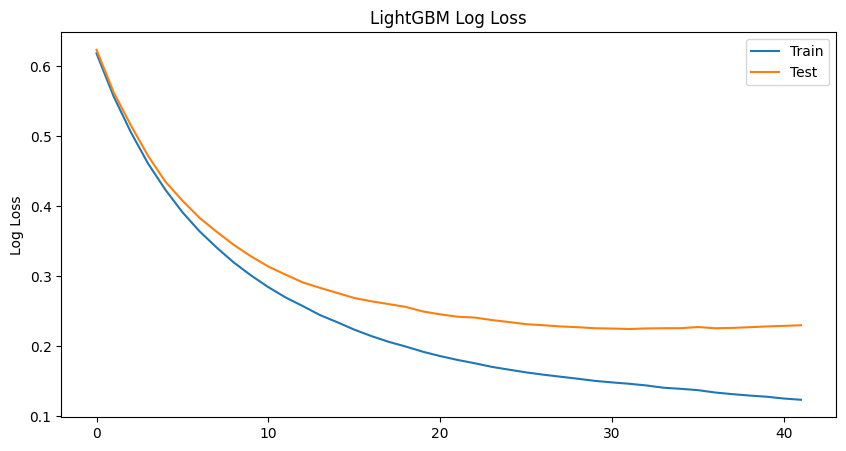

In [ ]:
# Визуализация Log Loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_axis, results['training']['binary_logloss'], label='Train')
ax.plot(x_axis, results['valid_1']['binary_logloss'], label='Test') #valid_1 потому что eval_set = [(X_train, y_train), (X_test, y_test)]
ax.legend()
plt.ylabel('Log Loss')
plt.title('LightGBM Log Loss')
plt.show()

# CatBoost   с графиком

In [ ]:
# 5. CatBoost с графиком


# Подготовка данных для CatBoost (используем Pool)-специальный класс для представления данных.
# Создаем объекты Pool для обучающей и тестовой выборок.
train_pool = Pool(data=X_train_scaled, label=y_train)
test_pool = Pool(data=X_test_scaled, label=y_test)


model = CatBoostClassifier(
    iterations=100, # Количество итераций (деревьев).
    learning_rate=0.1, # Темп обучения.
    depth=3,           # Глубина дерева.
    l2_leaf_reg=3,     # L2 регуляризация
    loss_function='Logloss', #  Функция потерь для бинарной классификации.
    eval_metric='Accuracy',  # Метрика для оценки производительности во время обучения.
    random_seed=42,
    verbose=0                # Убираем лишний вывод
)

model.fit(train_pool, eval_set=test_pool, verbose=False)

# Получение количества итераций, которое реально выполнила модель
num_iterations = model.get_best_iteration() + 1  # +1 потому что итерации начинаются с 0


In [ ]:
print(num_iterations)

21


In [ ]:
# Получение значений Accuracy на каждой итерации
#Мы обрезаем массивы train_evals и test_evals до длины num_iterations. Это гарантирует, что длина массивов для оси X и оси Y совпадает.
train_evals = model.eval_metrics(train_pool, ['Accuracy'])['Accuracy'][:num_iterations]
test_evals = model.eval_metrics(test_pool, ['Accuracy'])['Accuracy'][:num_iterations]


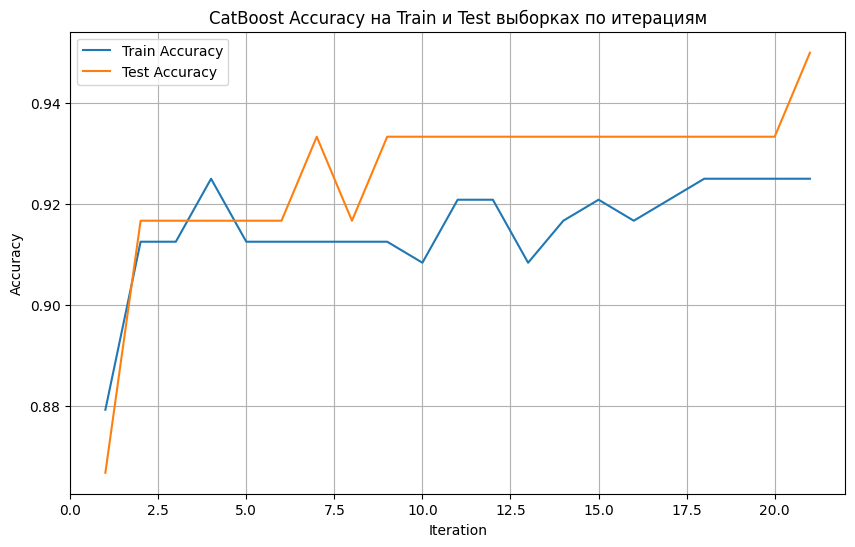

In [ ]:
# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_iterations + 1), train_evals, label='Train Accuracy')
plt.plot(range(1, num_iterations + 1), test_evals, label='Test Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('CatBoost Accuracy на Train и Test выборках по итерациям')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Оценка финальной модели
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Final Train Accuracy: {train_accuracy:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Train Accuracy: 0.9250
Final Test Accuracy: 0.9500
